## Import libraries

In [2]:
import sys
from pathlib import Path

sys.path.insert(0, "../scripts")
from segmentation_utils import cluster_chroms, cluster_summary, segment_by_chromhmm
from clock_utils import build_cluster_X

import glob
import os
from multiprocessing import Pool

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyBigWig
import seaborn as sns
from scipy.stats import mannwhitneyu
from sklearn.cluster import DBSCAN, HDBSCAN, OPTICS
from sklearn.decomposition import PCA
from sklearn.metrics import davies_bouldin_score, silhouette_score


## Configuration

In [ ]:
BW_DIR = "../sources/obesity_GSE85928"  # directory containing *.bw files

# Group assignment: samples whose name contains GROUP_B_PATTERN → Group B
GROUP_B_PATTERN = "Obese"
GROUP_A_NAME = "Lean"
GROUP_B_NAME = "Obese"

P_THRESHOLD = 0.3  # nominal p-value threshold for DM CpG selection, it is not a strict threshold, just a way to select a subset of CpGs 

DBSCAN_PARAMS  = dict(eps=1000, min_samples=5)
HDBSCAN_PARAMS = dict(min_cluster_size=5, min_samples=5, copy=True)
OPTICS_PARAMS  = dict(min_samples=5, xi=0.25, min_cluster_size=5)

# ChromHMM segmentation for E062 (primary blood) from Roadmap Epigenomics
CHROMHMM_BED_HUMAN = Path(
    "../sources/human_Roadmap_Epigenomics_chromhmmSegmentations/E062_15_coreMarks_dense.bed.gz"
)

## Output directories

In [4]:
output_dir = Path("../outputs/02_methylation_group_separation")
plots_dir  = output_dir / "plots"
output_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)

PALETTE = {GROUP_A_NAME: "#3498db", GROUP_B_NAME: "#e74c3c"}

# Two-group RRBS methylation analysis: group separation

## Load data

In [5]:
def load_bw(path: str) -> pd.Series:
    bw = pyBigWig.open(path)
    data = {
        f"{chrom}_{start}": np.float32(val)
        for chrom in bw.chroms()
        for start, _, val in (bw.intervals(chrom) or [])
    }
    bw.close()
    return pd.Series(data, dtype=np.float32)


bw_files = sorted(glob.glob(f"{BW_DIR}/*.bw"))
samples = [os.path.basename(f).replace(".bw", "") for f in bw_files]
labels = np.where([GROUP_B_PATTERN in s for s in samples], GROUP_B_NAME, GROUP_A_NAME)

with Pool() as pool:
    series_list = pool.map(load_bw, bw_files)

meth = pd.DataFrame(dict(zip(samples, series_list)))  # CpGs × samples
print(
    f"Samples: {len(samples)}  ({(labels == GROUP_A_NAME).sum()} {GROUP_A_NAME}, {(labels == GROUP_B_NAME).sum()} {GROUP_B_NAME})"
)
print(f"Raw matrix: {meth.shape}")


Samples: 20  (10 Lean, 10 Obese)
Raw matrix: (5157869, 20)


## Outlier detection

IQR × 1.5 outlier flag on the first 3 PCs of PCA computed on fully-observed CpGs (no NaN in any sample).

Complete CpGs (no NaN in any sample): 961,470
Outliers (4): ['GSM2287933_T06_Lean', 'GSM2287935_T09_Lean', 'GSM2287940_T07_Obese', 'GSM2287941_T10_Obese']
Retained: 16 / 20 samples


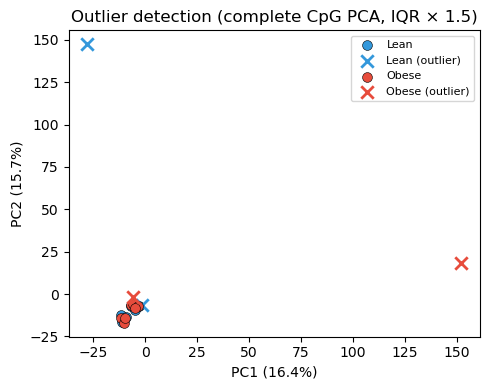

In [6]:
meth_complete = meth.dropna(how="any")  # CpGs with no NaN in any sample
X_pre = meth_complete.T.values.astype(np.float32)

pca_pre = PCA(n_components=5, random_state=42)
pcs_pre = pca_pre.fit_transform(X_pre)

q1, q3 = np.percentile(pcs_pre, [25, 75], axis=0)
fence = 1.5 * (q3 - q1)
outlier_mask = ((pcs_pre < q1 - fence) | (pcs_pre > q3 + fence)).any(axis=1)
ok = ~outlier_mask
labels_ok = labels[ok]
print(f"Complete CpGs (no NaN in any sample): {len(meth_complete):,}")
print(f"Outliers ({outlier_mask.sum()}): {np.array(samples)[outlier_mask].tolist()}")
print(f"Retained: {ok.sum()} / {len(samples)} samples")

fig, ax = plt.subplots(figsize=(5, 4))
for grp, color in PALETTE.items():
    grp_mask = labels == grp
    ax.scatter(
        pcs_pre[grp_mask & ok, 0],
        pcs_pre[grp_mask & ok, 1],
        s=50,
        color=color,
        edgecolors="k",
        lw=0.4,
        label=grp,
    )
    ax.scatter(
        pcs_pre[grp_mask & ~ok, 0],
        pcs_pre[grp_mask & ~ok, 1],
        s=80,
        color=color,
        marker="x",
        lw=2,
        label=f"{grp} (outlier)",
    )
ax.set_xlabel(f"PC1 ({pca_pre.explained_variance_ratio_[0] * 100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_pre.explained_variance_ratio_[1] * 100:.1f}%)")
ax.set_title("Outlier detection (complete CpG PCA, IQR × 1.5)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(plots_dir / "outlier_detection.png", dpi=150, bbox_inches="tight")
plt.show()


## Preprocessing

Remove CpGs that are not covered in at least 6 samples (80%) in each group (applied after outlier removal).
Impute remaining NaN with per-CpG mean across all samples.


In [7]:
meth_ok = meth.loc[:, ok]

n_a = (labels_ok == GROUP_A_NAME).sum()
n_b = (labels_ok == GROUP_B_NAME).sum()
mask_a = labels_ok == GROUP_A_NAME
mask_b = labels_ok == GROUP_B_NAME

cov_a = meth_ok.loc[:, mask_a].notna().sum(axis=1)
cov_b = meth_ok.loc[:, mask_b].notna().sum(axis=1)
meth_filt = meth_ok[(cov_a >= n_a - 2) & (cov_b >= n_b - 2)]
print(f"CpGs after per-group coverage filter (≥ n-1 per group): {len(meth_filt):,} / {len(meth):,}")


CpGs after per-group coverage filter (≥ n-1 per group): 3,308,501 / 5,157,869


In [8]:
arr = meth_filt.values.astype(np.float32)

overall_means = np.nanmean(arr, axis=1, keepdims=True)
nan_mask = np.isnan(arr)
arr[nan_mask] = np.broadcast_to(overall_means, arr.shape)[nan_mask]

meth_imputed = pd.DataFrame(arr, index=meth_filt.index, columns=meth_filt.columns)
X = arr.T  # non-outlier samples × CpGs, no NaN
print(f"Feature matrix X: {X.shape}")

Feature matrix X: (16, 3308501)


## DBSCAN segmentation — all CpGs


In [9]:
# site_coords_all = pd.DataFrame(
#     {
#         "chrom": meth_filt.index.str.rsplit("_", n=1).str[0],
#         "pos": meth_filt.index.str.rsplit("_", n=1).str[1].astype(int),
#     },
#     index=meth_filt.index,
# )
# site_coords_all["cluster_dbs"] = cluster_chroms(
#     list(site_coords_all.groupby("chrom")), site_coords_all.index, DBSCAN, DBSCAN_PARAMS
# )
# site_coords_all.to_parquet(output_dir / "site_coords_all_clustered.parquet")



DBSCAN (all CpGs)
Clusters:         115,367
Noise CpGs:       209,939  (6.3%)
Clustered CpGs: 3,098,562  (93.7%)

CpGs per cluster:
  mean:       26.9
  median:     10.0
  std:        45.5
  min:           4
  p25:           7
  p75:          22
  p90:          70
  p99:         227
  max:        1016


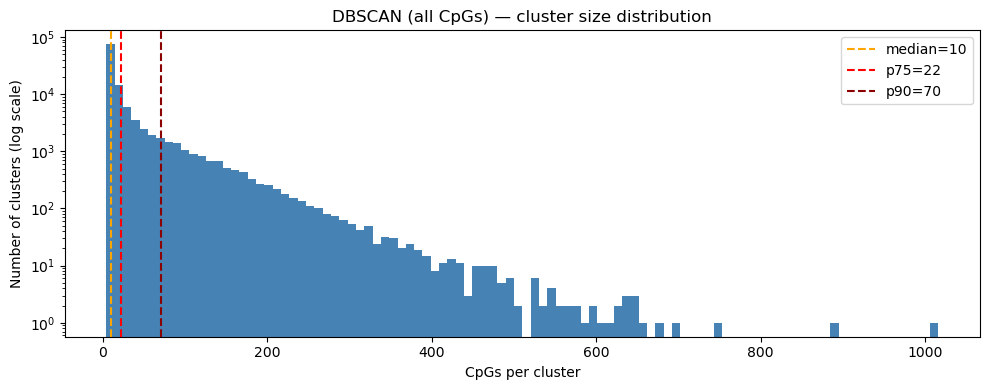

DBSCAN regions (all CpGs): 115,367


In [10]:
site_coords_all = pd.read_parquet(output_dir / "site_coords_all_clustered.parquet")
cluster_summary(site_coords_all["cluster_dbs"], name="DBSCAN (all CpGs)", plot_dir=plots_dir)
X_all_dbs = build_cluster_X(meth_imputed, site_coords_all, "cluster_dbs")
print(f"DBSCAN regions (all CpGs): {X_all_dbs.shape[1]:,}")


## ChromHMM-based segmentation — all CpGs

Human ChromHMM annotation is taken from the Roadmap Epigenomics Consortium for E062 Primary mononuclear cells from peripheral blood, as they are most close to the whole blood sample representation. The annotation file was downloaded from https://egg2.wustl.edu/roadmap/data/byFileType/chromhmmSegmentations/ChmmModels/coreMarks/jointModel/final/E062_15_coreMarks_dense.bed.gz on 15.05.2026. The 15-state core model uses the hg19 genome assembly.

In [11]:
X_all_chromhmm = segment_by_chromhmm(meth_imputed, CHROMHMM_BED_HUMAN, min_cpgs=5)
print(f"ChromHMM segments (all CpGs): {X_all_chromhmm.shape[1]:,}")

ChromHMM segments (all CpGs): 103,419


## HDBSCAN segmentation — all CpGs

In [12]:
# site_coords_all_h = pd.DataFrame(
#     {
#         "chrom": meth_filt.index.str.rsplit("_", n=1).str[0],
#         "pos":   meth_filt.index.str.rsplit("_", n=1).str[1].astype(int),
#     },
#     index=meth_filt.index,
# )
# site_coords_all_h["cluster_hdbscan"] = cluster_chroms(
#     list(site_coords_all_h.groupby("chrom")), site_coords_all_h.index, HDBSCAN, HDBSCAN_PARAMS
# )
# site_coords_all_h.to_parquet(output_dir / "site_coords_all_hdbscan_clustered.parquet")


HDBSCAN (all CpGs)
Clusters:         298,375
Noise CpGs:       254,130  (7.7%)
Clustered CpGs: 3,054,371  (92.3%)

CpGs per cluster:
  mean:       10.2
  median:      9.0
  std:         5.5
  min:           5
  p25:           6
  p75:          12
  p90:          17
  p99:          30
  max:         110


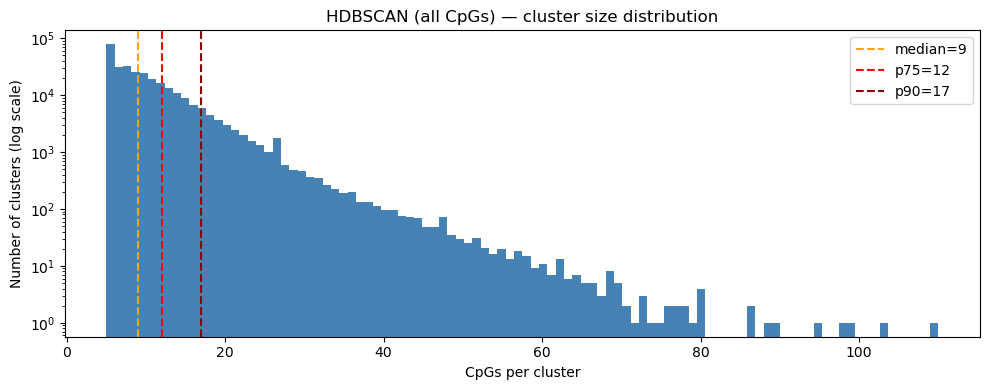

HDBSCAN regions (all CpGs): 298,375


In [13]:
site_coords_all_h = pd.read_parquet(output_dir / "site_coords_all_hdbscan_clustered.parquet")
cluster_summary(site_coords_all_h["cluster_hdbscan"], name="HDBSCAN (all CpGs)", plot_dir=plots_dir)
X_all_hdbscan = build_cluster_X(meth_imputed, site_coords_all_h, "cluster_hdbscan")
print(f"HDBSCAN regions (all CpGs): {X_all_hdbscan.shape[1]:,}")

## OPTICS segmentation — all CpGs

In [ ]:
# site_coords_all_o = pd.DataFrame(
#     {
#         "chrom": meth_filt.index.str.rsplit("_", n=1).str[0],
#         "pos":   meth_filt.index.str.rsplit("_", n=1).str[1].astype(int),
#     },
#     index=meth_filt.index,
# )
# site_coords_all_o["cluster_optics"] = cluster_chroms(
#     list(site_coords_all_o.groupby("chrom")), site_coords_all_o.index, OPTICS, OPTICS_PARAMS
# )
# site_coords_all_o.to_parquet(output_dir / "site_coords_all_optics_clustered.parquet")


OPTICS (all CpGs)
Clusters:         299,815
Noise CpGs:       762,185  (23.0%)
Clustered CpGs: 2,546,316  (77.0%)

CpGs per cluster:
  mean:        8.5
  median:      8.0
  std:         3.2
  min:           5
  p25:           6
  p75:          10
  p90:          13
  p99:          19
  max:          47


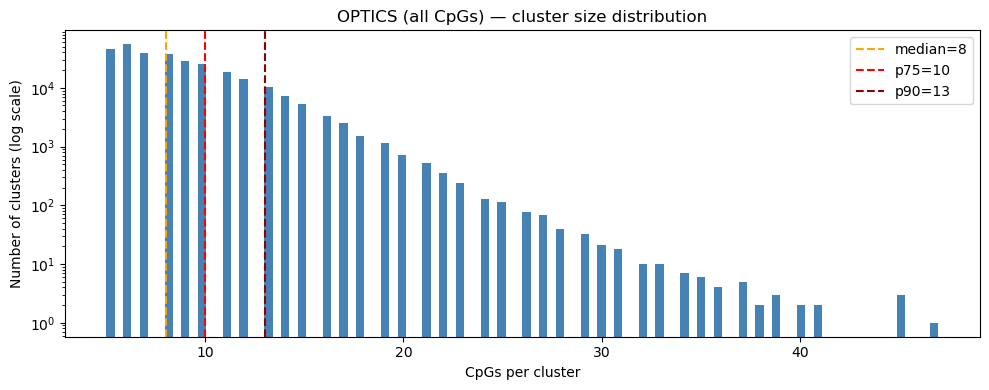

OPTICS regions (all CpGs): 299,815


In [17]:
site_coords_all_o = pd.read_parquet(output_dir / "site_coords_all_optics_clustered.parquet")
cluster_summary(site_coords_all_o["cluster_optics"], name="OPTICS (all CpGs)", plot_dir=plots_dir)
X_all_optics = build_cluster_X(meth_imputed, site_coords_all_o, "cluster_optics")
print(f"OPTICS regions (all CpGs): {X_all_optics.shape[1]:,}")

## Differential methylation

### Mann-Whitney U test

We test all CpGs for differential methylation between groups. FDR correction is intentionally omitted: with ~2.8M sites and a modest sample size, BH correction renders every site non-significant, leaving no DM set to evaluate.

Instead, we use a nominal p < 0.05 threshold to construct an **artificial enriched subset** — CpGs that are *likely* to separate the groups. This is not a rigorous DM (differential methylation) call; it is a benchmark condition. By comparing PCA separation on (1) all CpGs and (2) this enriched subset we can assess whether DBSCAN clustering improves group separability under both a realistic (unsupervised, all features) and an idealized (signal-enriched features) scenario.


In [18]:
a_idx = np.where(mask_a)[0]
b_idx = np.where(mask_b)[0]
chunks = np.array_split(X, os.cpu_count(), axis=1)

def _mw_chunk(col_chunk):
    _, p = mannwhitneyu(
        col_chunk[a_idx], col_chunk[b_idx],
        axis=0, alternative="two-sided", method="asymptotic",
    )
    return p

with Pool() as pool:
    pval_chunks = pool.map(_mw_chunk, chunks)

pvals = np.concatenate(pval_chunks)
mean_diff = X[mask_b].mean(axis=0) - X[mask_a].mean(axis=0)
print(f"CpGs tested: {len(pvals):,}")


CpGs tested: 3,308,501


### DM site selection (p < P_THRESHOLD, no multiple-testing correction)


In [19]:
dm_mask = pvals < P_THRESHOLD
dm_cpgs = meth_filt.index[dm_mask]
print(f"DM CpGs (p < {P_THRESHOLD}): {dm_mask.sum():,} / {len(pvals):,}")


DM CpGs (p < 0.3): 585,799 / 3,308,501


## DBSCAN segmentation — DM CpGs


In [ ]:
# site_coords_dm = pd.DataFrame(
#     {
#         "chrom": dm_cpgs.str.rsplit("_", n=1).str[0],
#         "pos": dm_cpgs.str.rsplit("_", n=1).str[1].astype(int),
#     },
#     index=dm_cpgs,
# )
# site_coords_dm["cluster_dbs"] = cluster_chroms(
#     list(site_coords_dm.groupby("chrom")), site_coords_dm.index, DBSCAN, DBSCAN_PARAMS
# )
# site_coords_dm.to_parquet(output_dir / "site_coords_dm_clustered.parquet")



DBSCAN (DM CpGs)
Clusters:          30,897
Noise CpGs:       217,572  (37.1%)
Clustered CpGs:   368,227  (62.9%)

CpGs per cluster:
  mean:       11.9
  median:      8.0
  std:        11.5
  min:           3
  p25:           6
  p75:          13
  p90:          23
  p99:          60
  max:         270


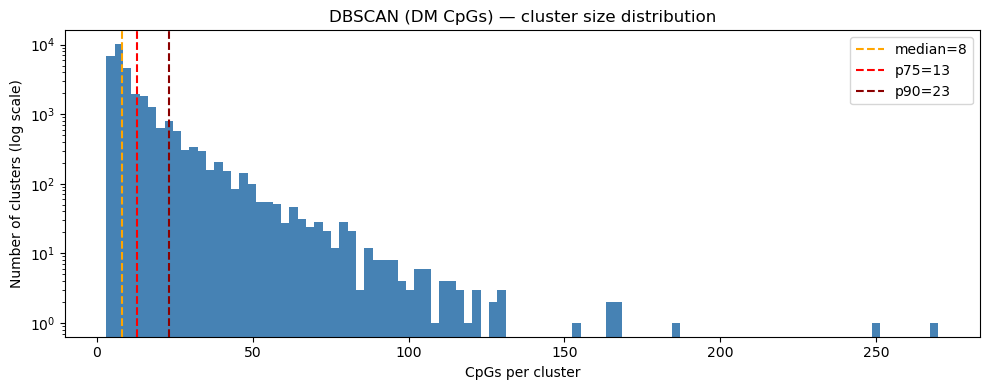

DBSCAN DMRs: 30,897


In [21]:
site_coords_dm = pd.read_parquet(output_dir / "site_coords_dm_clustered.parquet")
cluster_summary(site_coords_dm["cluster_dbs"], name="DBSCAN (DM CpGs)", plot_dir=plots_dir)
X_dm_dbs = build_cluster_X(meth_imputed.loc[dm_cpgs], site_coords_dm, "cluster_dbs")
print(f"DBSCAN DMRs: {X_dm_dbs.shape[1]:,}")

## ChromHMM-based segmentation — DM CpGs

In [22]:
X_dm_chromhmm = segment_by_chromhmm(
    meth_imputed.loc[dm_cpgs], CHROMHMM_BED_HUMAN, min_cpgs=5
)
print(f"ChromHMM segments (DM CpGs):  {X_dm_chromhmm.shape[1]:,}")

ChromHMM segments (DM CpGs):  37,325


## HDBSCAN segmentation — DM CpGs

In [ ]:
# # Run once, then comment out
# site_coords_dm_h = pd.DataFrame(
#     {
#         "chrom": dm_cpgs.str.rsplit("_", n=1).str[0],
#         "pos":   dm_cpgs.str.rsplit("_", n=1).str[1].astype(int),
#     },
#     index=dm_cpgs,
# )
# site_coords_dm_h["cluster_hdbscan"] = cluster_chroms(
#     list(site_coords_dm_h.groupby("chrom")), site_coords_dm_h.index, HDBSCAN, HDBSCAN_PARAMS
# )
# site_coords_dm_h.to_parquet(output_dir / "site_coords_dm_hdbscan_clustered.parquet")


HDBSCAN (DM CpGs)
Clusters:          55,732
Noise CpGs:        70,350  (12.0%)
Clustered CpGs:   515,449  (88.0%)

CpGs per cluster:
  mean:        9.2
  median:      8.0
  std:         4.3
  min:           5
  p25:           6
  p75:          11
  p90:          15
  p99:          24
  max:          78


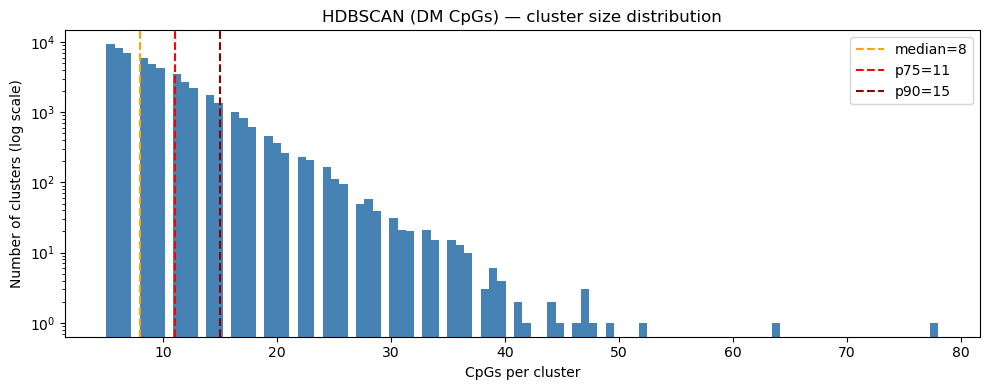

HDBSCAN DMRs: 55,732


In [24]:
site_coords_dm_h = pd.read_parquet(output_dir / "site_coords_dm_hdbscan_clustered.parquet")
cluster_summary(site_coords_dm_h["cluster_hdbscan"], name="HDBSCAN (DM CpGs)", plot_dir=plots_dir)
X_dm_hdbscan = build_cluster_X(meth_imputed.loc[dm_cpgs], site_coords_dm_h, "cluster_hdbscan")
print(f"HDBSCAN DMRs: {X_dm_hdbscan.shape[1]:,}")

## OPTICS segmentation — DM CpGs

In [27]:
# # Run once, then comment out
# site_coords_dm_o = pd.DataFrame(
#     {
#         "chrom": dm_cpgs.str.rsplit("_", n=1).str[0],
#         "pos":   dm_cpgs.str.rsplit("_", n=1).str[1].astype(int),
#     },
#     index=dm_cpgs,
# )
# site_coords_dm_o["cluster_optics"] = cluster_chroms(
#     list(site_coords_dm_o.groupby("chrom")), site_coords_dm_o.index, OPTICS, OPTICS_PARAMS
# )
# site_coords_dm_o.to_parquet(output_dir / "site_coords_dm_optics_clustered.parquet")


OPTICS (DM CpGs)
Clusters:          53,341
Noise CpGs:       139,074  (23.7%)
Clustered CpGs:   446,725  (76.3%)

CpGs per cluster:
  mean:        8.4
  median:      8.0
  std:         3.2
  min:           5
  p25:           6
  p75:          10
  p90:          13
  p99:          19
  max:          50


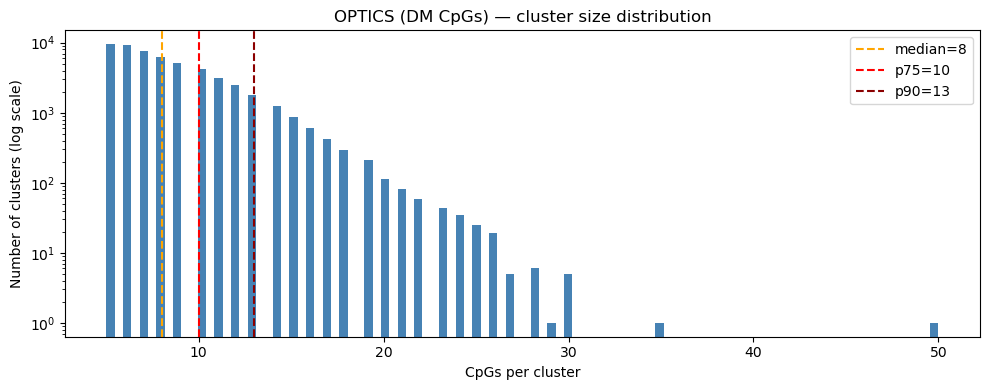

OPTICS DMRs: 53,341


In [28]:
site_coords_dm_o = pd.read_parquet(output_dir / "site_coords_dm_optics_clustered.parquet")
cluster_summary(site_coords_dm_o["cluster_optics"], name="OPTICS (DM CpGs)", plot_dir=plots_dir)
X_dm_optics = build_cluster_X(meth_imputed.loc[dm_cpgs], site_coords_dm_o, "cluster_optics")
print(f"OPTICS DMRs: {X_dm_optics.shape[1]:,}")

## PCA analysis

In [29]:
def run_pca_plot(X_feat, labels, title, save_path, n_components=16):
    """Fit PCA, produce PC1 vs PC2 scatter coloured by group, return (pcs, pca)."""
    n_comp = min(n_components, X_feat.shape[0] - 1, X_feat.shape[1])
    pca = PCA(n_components=n_comp, random_state=42)
    pcs = pca.fit_transform(X_feat)
    var = pca.explained_variance_ratio_ * 100

    fig, ax = plt.subplots(figsize=(6, 5))
    for grp, color in PALETTE.items():
        mask = labels == grp
        ax.scatter(
            pcs[mask, 0],
            pcs[mask, 1],
            s=60,
            color=color,
            edgecolors="k",
            linewidths=0.4,
            label=grp,
            zorder=3,
        )
    ax.set_xlabel(f"PC1 ({var[0]:.1f}%)")
    ax.set_ylabel(f"PC2 ({var[1]:.1f}%)")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    return pcs, pca

### PCA 1: Raw CpGs


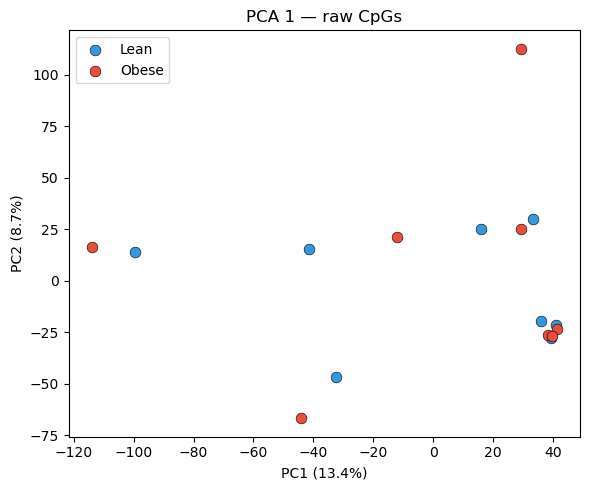

In [30]:
pcs_raw, pca_raw = run_pca_plot(
    X, labels_ok,
    "PCA 1 — raw CpGs",
    plots_dir / "pca_01_raw_cpg.png",
)


### PCA 2: DBSCAN regions (all CpGs)


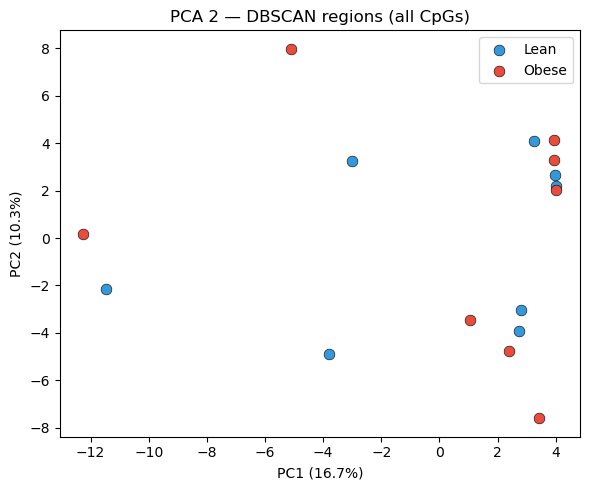

In [31]:
pcs_raw_dbs, pca_raw_dbs = run_pca_plot(
    X_all_dbs.values, labels_ok,
    "PCA 2 — DBSCAN regions (all CpGs)",
    plots_dir / "pca_02_all_dbscan.png",
)


### PCA 3: HDBSCAN regions (all CpGs)

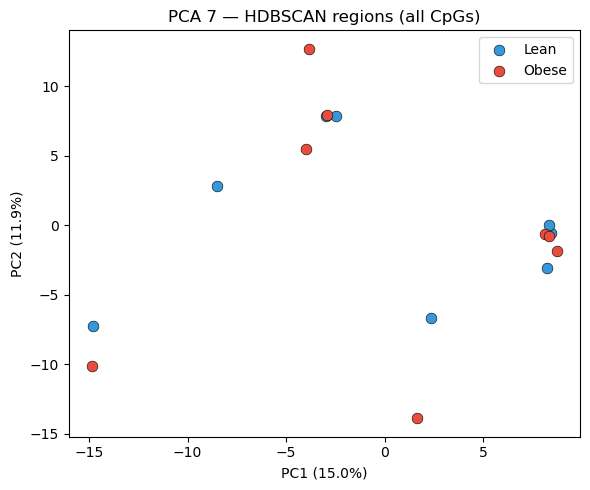

In [32]:
pcs_all_hdbscan, pca_all_hdbscan = run_pca_plot(
    X_all_hdbscan.values, labels_ok,
    "PCA 7 — HDBSCAN regions (all CpGs)",
    plots_dir / "pca_07_all_hdbscan.png",
)

### PCA 4: OPTICS regions (all CpGs)

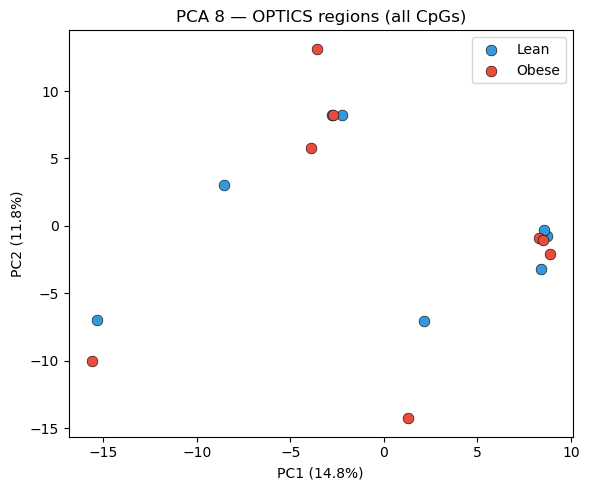

In [33]:
pcs_all_optics, pca_all_optics = run_pca_plot(
    X_all_optics.values, labels_ok,
    "PCA 8 — OPTICS regions (all CpGs)",
    plots_dir / "pca_08_all_optics.png",
)

### PCA 5: ChromHMM regional (all CpGs)

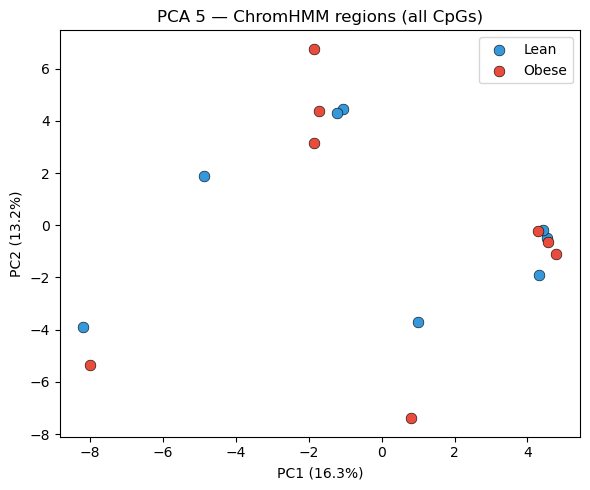

In [34]:
pcs_all_chromhmm, pca_all_chromhmm = run_pca_plot(
    X_all_chromhmm.values, labels_ok,
    "PCA 5 \u2014 ChromHMM regions (all CpGs)",
    plots_dir / "pca_05_all_chromhmm.png",
)

### PCA 6: DM CpGs (p < P_THRESHOLD, before correction)


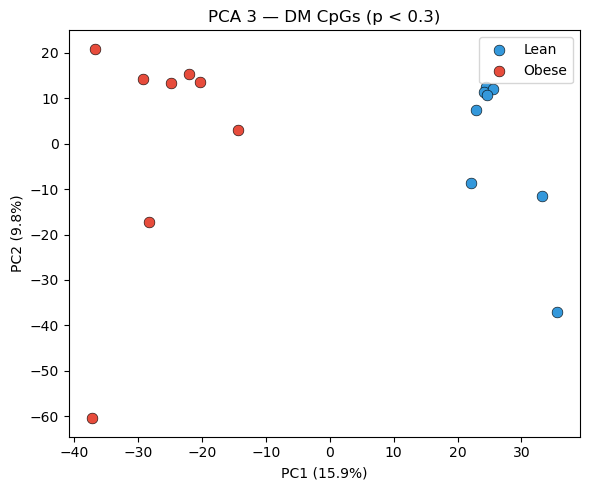

In [35]:
pcs_dm, pca_dm = run_pca_plot(
    X[:, dm_mask], labels_ok,
    f"PCA 3 — DM CpGs (p < {P_THRESHOLD})",
    plots_dir / "pca_03_dm_cpg.png",
)


### PCA 7: DBSCAN DMRs (DM CpGs segmented)


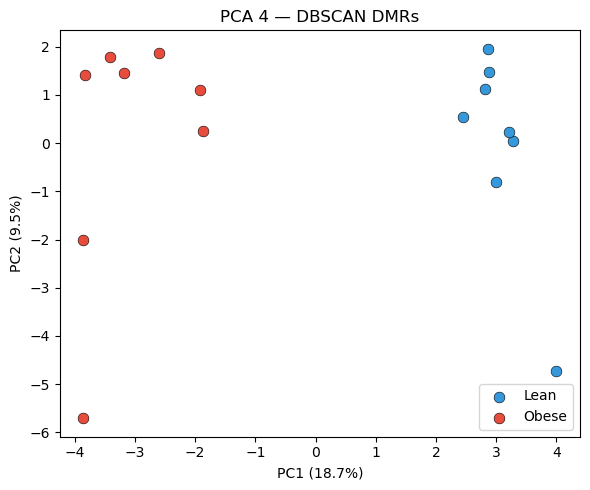

In [36]:
pcs_dm_dbs, pca_dm_dbs = run_pca_plot(
    X_dm_dbs.values, labels_ok,
    "PCA 4 — DBSCAN DMRs",
    plots_dir / "pca_04_dm_dbscan.png",
)

### PCA 8: HDBSCAN DMRs

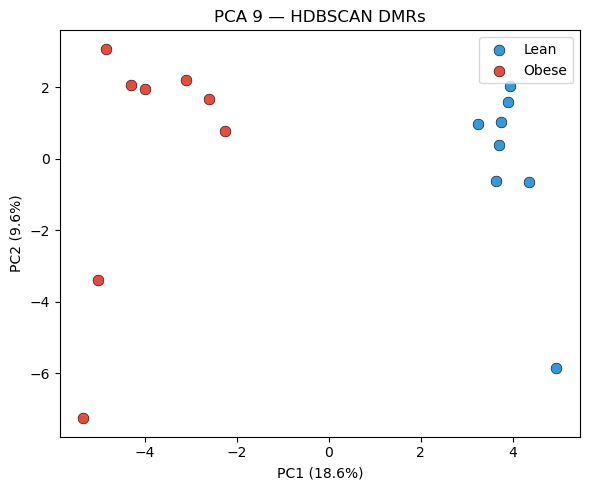

In [37]:
pcs_dm_hdbscan, pca_dm_hdbscan = run_pca_plot(
    X_dm_hdbscan.values, labels_ok,
    "PCA 9 — HDBSCAN DMRs",
    plots_dir / "pca_09_dm_hdbscan.png",
)

### PCA 9: OPTICS DMRs

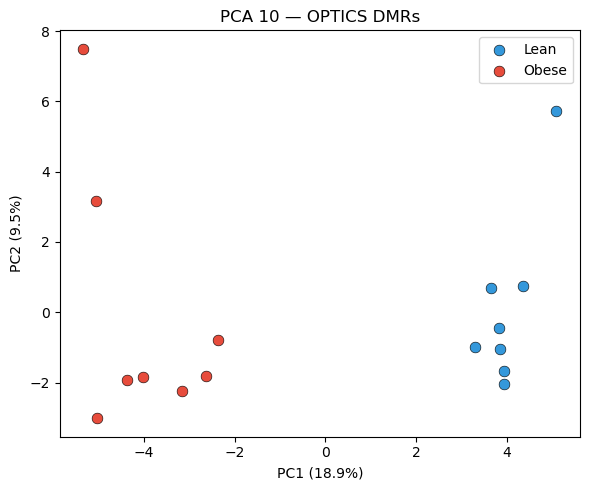

In [38]:
pcs_dm_optics, pca_dm_optics = run_pca_plot(
    X_dm_optics.values, labels_ok,
    "PCA 10 — OPTICS DMRs",
    plots_dir / "pca_10_dm_optics.png",
)

### PCA 10: ChromHMM on DM CpGs

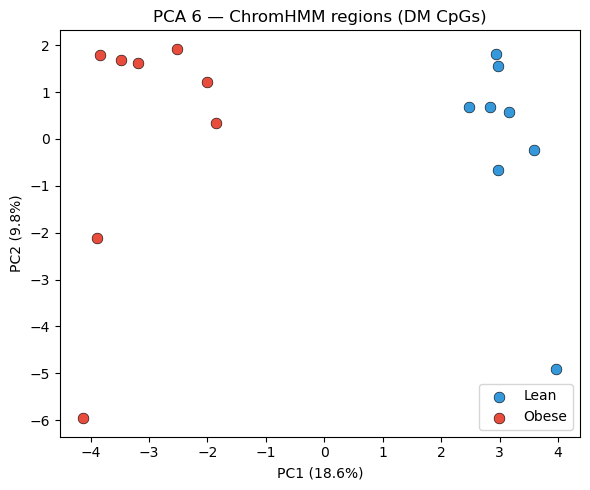

In [39]:
pcs_dm_chromhmm, pca_dm_chromhmm = run_pca_plot(
    X_dm_chromhmm.values, labels_ok,
    "PCA 6 \u2014 ChromHMM regions (DM CpGs)",
    plots_dir / "pca_06_dm_chromhmm.png",
)

## Group separation metrics

In [42]:
def separation_metrics(pcs, pca, labels, name):
    """Silhouette and Davies-Bouldin on PCs explaining ≥90% cumulative variance."""
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    n_pc = int(np.searchsorted(cumvar, 0.90) + 1)
    n_pc = min(n_pc, pcs.shape[1])
    coords = pcs[:, :n_pc]
    return {
        "Feature set": name,
        "PCs (≥90% var)": n_pc,
        "Silhouette ↑": round(silhouette_score(coords, labels), 4),
        "Davies-Bouldin ↓": round(davies_bouldin_score(coords, labels), 4),
    }


metrics_df = pd.DataFrame(
    [
        separation_metrics(pcs_raw, pca_raw, labels_ok, "Raw CpGs"),
        separation_metrics(
            pcs_raw_dbs, pca_raw_dbs, labels_ok, "DBSCAN regions (all CpGs)"
        ),
        separation_metrics(
            pcs_all_hdbscan, pca_all_hdbscan, labels_ok, "HDBSCAN regions (all CpGs)"
        ),
        separation_metrics(
            pcs_all_optics, pca_all_optics, labels_ok, "OPTICS regions (all CpGs)"
        ),
        separation_metrics(
            pcs_all_chromhmm, pca_all_chromhmm, labels_ok, "ChromHMM regions (all CpGs)"
        ),
        separation_metrics(pcs_dm, pca_dm, labels_ok, f"DM CpGs (p < {P_THRESHOLD})"),
        separation_metrics(pcs_dm_dbs, pca_dm_dbs, labels_ok, "DBSCAN DMRs"),
        separation_metrics(pcs_dm_hdbscan, pca_dm_hdbscan, labels_ok, "HDBSCAN DMRs"),
        separation_metrics(pcs_dm_optics, pca_dm_optics, labels_ok, "OPTICS DMRs"),
        separation_metrics(
            pcs_dm_chromhmm, pca_dm_chromhmm, labels_ok, "ChromHMM regions (DM CpGs)"
        ),
    ]
).set_index("Feature set")

print(metrics_df.to_string())
metrics_df.to_csv(output_dir / "separation_metrics.csv")


                             PCs (≥90% var)  Silhouette ↑  Davies-Bouldin ↓
Feature set                                                                
Raw CpGs                                 13       -0.0097            4.0476
DBSCAN regions (all CpGs)                13       -0.0194            4.2300
HDBSCAN regions (all CpGs)               13       -0.0223            4.3256
OPTICS regions (all CpGs)                13       -0.0217            4.3165
ChromHMM regions (all CpGs)              13       -0.0250            4.4951
DM CpGs (p < 0.3)                        13        0.1005            2.1828
DBSCAN DMRs                              13        0.1259            1.9866
HDBSCAN DMRs                             13        0.1244            1.9908
OPTICS DMRs                              13        0.1275            1.9696
ChromHMM regions (DM CpGs)               13        0.1247            1.9903


## Summary table

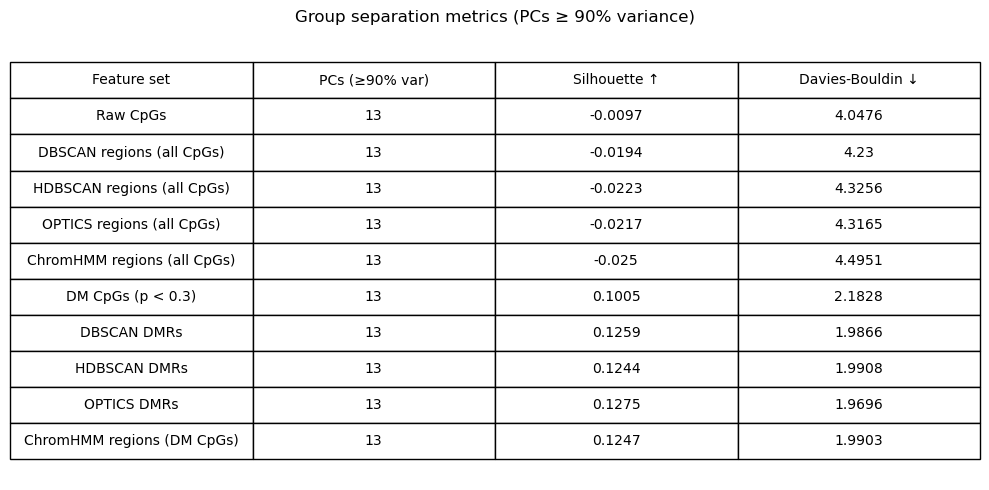

In [44]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis("off")
tbl = ax.table(
    cellText=metrics_df.reset_index().values,
    colLabels=["Feature set", "PCs (≥90% var)", "Silhouette ↑", "Davies-Bouldin ↓"],
    cellLoc="center",
    loc="center",
)
tbl.scale(1, 1.9)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
ax.set_title("Group separation metrics (PCs ≥ 90% variance)", pad=14)
plt.tight_layout()
plt.savefig(plots_dir / "separation_metrics_table.png", dpi=200, bbox_inches="tight")
plt.show()